In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.spatial.distance import cdist
from scipy.stats import zscore
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import gseapy as gp
from gseapy.parser import download_library
from gseapy import barplot, dotplot
from matplotlib_venn import venn2, venn3
import textwrap
from matplotlib_venn import venn3_unweighted
import matplotlib.colors as mcolors
from collections import defaultdict
from collections import Counter

sc.settings.verbosity = 2
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.4 umap==0.5.7 numpy==1.26.4 scipy==1.15.2 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.6 pynndescent==0.5.13


# Load in Marker Genes / Databases

### PanglaoDB

In [2]:
### PanglaoDB marker genes
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "/nfs/turbo/umms-indikar/shared/projects/RECODE/marker_genes/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563


label,Fibroblasts,Myocytes,Myoblasts,Myofibroblasts,Pluripotent Stem Cells
RARRES2,True,False,False,False,False
CELA1,True,False,False,False,False
LUM,True,False,True,True,False
PRRX1,True,True,True,True,False
SCARA5,True,False,False,False,False


### TFs

In [3]:
### Transcription Factors
tfpath = "../resources/allTFs_hg38.txt"

with open(tfpath, 'r') as file:
    tf_list = [line.strip() for line in file]

print(len(tf_list))

1892


### GO processes

In [40]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2023, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),5S Class rRNA Transcription By RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),7-Methylguanosine mRNA Capping (GO:0006370),...,Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Glucuronidation (GO:0052697),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638),Zymogen Inhibition (GO:0097341)
0,ATIC,SDF2L1,IDH1,UPF1,DAZ4,PAPSS1,GTF3C2,RNGTT,SNRPD3,RNGTT,...,TYW5,GSTM4,UGT2B28,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,FGB,CAST
1,PAICS,HSPA9,PHYH,TRIM71,TIRAP,PAPSS2,GTF3C3,RNMT,SNRPD2,RNMT,...,TYW3,GSTM3,UGT1A6,SLC22A4,SLC22A1,SLC30A7,SLC39A1,SLC39A1,F11,XIAP
2,PFAS,CCT2,GOT2,RC3H1,DAZ3,SULT1A2,GTF3C4,NCBP1,SNRPD1,NCBP1,...,TYW1,GSTM2,UGT2B4,ABCB1,SLC22A2,SLC30A6,SLC30A4,SLC30A9,FGG,CARD18
3,ADSS1,HSPA6,MRPS36,ZFP36L1,YBX3,SULT1C4,GTF3C5,CMTR2,TGS1,CMTR2,...,TRMT12,GSTM1,UGT1A9,ABCC2,ABCC1,SLC30A5,SLC30A3,SLC30A4,BAD,CARD8
4,ADSS2,ST13,GOT1,ZFP36L2,DAZ2,SULT2A1,GTF3C6,RAMAC,SNRPF,RAMAC,...,TYW1B,NR1I2,UGT1A8,SLC15A2,ABCG2,SLC30A2,SLC30A5,SLC30A3,F12,CST7


In [43]:
[col for col in geneset if "transcription factor" in col.lower()]

['Cytoplasmic Sequestering Of Transcription Factor (GO:0042994)',
 'Negative Regulation Of DNA-binding Transcription Factor Activity (GO:0043433)',
 'Negative Regulation Of NF-kappaB Transcription Factor Activity (GO:0032088)',
 'Positive Regulation Of CREB Transcription Factor Activity (GO:0032793)',
 'Positive Regulation Of DNA-binding Transcription Factor Activity (GO:0051091)',
 'Positive Regulation Of NF-kappaB Transcription Factor Activity (GO:0051092)']

In [45]:
# Chromatin remodeling
chromatin_terms = [col for col in geneset if "chromatin" in col.lower()]
print(f"N chromatin terms: {len(chromatin_terms)}")
df = geneset[chromatin_terms]
chromatin_genes = list(set(df.stack().tolist()))
print(f"N chromatin genes: {len(chromatin_genes)}\n")

# DNA damage genes
damage_terms = [col for col in geneset if "dna damage" in col.lower()]
print(f"N dna damage terms: {len(damage_terms)}")
df = geneset[damage_terms]
damage_genes = list(set(df.stack().tolist()))
print(f"N dna damage genes: {len(damage_genes)}\n")


# TF activity 
tf_terms = [
    'Positive Regulation Of DNA-binding Transcription Factor Activity (GO:0051091)',
    'Negative Regulation Of DNA-binding Transcription Factor Activity (GO:0043433)',
]
print(f"N TF activity terms: {len(tf_terms)}")
df = geneset[tf_terms]
tf_genes = list(set(df.stack().tolist()))
print(f"N TF activity genes: {len(tf_genes)}\n")


# Senescence genes
senescence_terms = [col for col in geneset if "senescence" in col.lower()]
print(f"N senescence terms: {len(senescence_terms)}")
df = geneset[senescence_terms]
senescence_genes = list(set(df.stack().tolist()))
print(f"N senescence genes: {len(senescence_genes)}\n")


# Circadian rythym genes
circadian_terms = [col for col in geneset if "circadian" in col.lower()]
print(f"N circadian terms: {len(circadian_terms)}")
df = geneset[circadian_terms]
circadian_genes = list(set(df.stack().tolist()))
print(f"N circadian genes: {len(circadian_genes)}\n")


# Alternative splicing genes
splice_terms = [col for col in geneset if "splice" in col.lower()]
print(f"N AS terms: {len(splice_terms)}")
df = geneset[splice_terms]
splice_genes = list(set(df.stack().tolist()))
print(f"N AS genes: {len(splice_genes)}\n")


# Cell cycle genes
cc_terms = [col for col in geneset if "cell cycle" in col.lower()]
print(f"N cell cycle terms: {len(cc_terms)}")
df = geneset[cc_terms]
cc_genes = list(set(df.stack().tolist()))
print(f"N cell cycle genes: {len(cc_genes)}\n")

N chromatin terms: 27
N chromatin genes: 435

N dna damage terms: 26
N dna damage genes: 509

N TF activity terms: 2
N TF activity genes: 375

N senescence terms: 4
N senescence genes: 40

N circadian terms: 5
N circadian genes: 44

N AS terms: 14
N AS genes: 277

N cell cycle terms: 44
N cell cycle genes: 826



### Other

In [6]:
### Core reprogramming regulators, cell cycle, and circadian genes from Liu 2018 paper (supplemental table S3, S4)
fpath = "../resources/liu_core_genes.csv"
df = pd.read_csv(fpath)

# core muscle and fibroblast reprogramming regulators
core_regulators = list(set(df[['Fibroblast', 'Muscle']].stack().tolist()))
print(f"N core regulators of MYOD1-mediated reprogramming: {len(core_regulators)}")

# core circadian genes
core_circadian = df['Circadian'].unique()
print(f"N core circadian genes: {len(core_circadian)}")

# combine with GO circadian genes
circadian = list(set(core_circadian) | set(circadian_genes))
print(f"N total circadian genes: {len(circadian)}\n")


### Cell-type specific marker genes from PanglaoDB 2021 and Tabula Sapiens
fpath = "../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)

cells = ['skeletal_muscle', 'myocyte', 'myoblast']
myogenic = mdf[mdf['category'].isin(cells)]['gene_name'].dropna().unique()
print(f"N skeletal muscle/myocyte/myoblast genes: {len(myogenic)}")

fibroblast = mdf[mdf['category'] == 'fibroblast']['gene_name'].dropna().unique()
print(f"N fibroblast genes: {len(fibroblast)}")

myofibroblast = mdf[mdf['category'] == 'myofibroblast']['gene_name'].dropna().unique()
print(f"N myofibroblast genes: {len(myofibroblast)}")

N core regulators of MYOD1-mediated reprogramming: 144
N core circadian genes: 28
N total circadian genes: 63

N skeletal muscle/myocyte/myoblast genes: 455
N fibroblast genes: 461
N myofibroblast genes: 240


In [46]:
### Combine into 1 data object
categories = {
    'TFs': tf_list,
    'Fibroblasts': fibroblast,
    'Myofibroblasts': myofibroblast,
    'Myogenic': myogenic,
    'cell_cycle': cc_genes,
    'AS': splice_genes,
    'Circadian': circadian,
    'Core_reprogramming': core_regulators,
    'Senescence': senescence_genes,
    'DNA_damage': damage_genes,
    'Chromatin_remodeling': chromatin_genes, 
    'TF_activity': tf_genes,
}

for key, gene_list in categories.items():
    # adata.uns[key] = gene_list
    print(f"N genes for {key}: {len(gene_list)}")

N genes for TFs: 1892
N genes for Fibroblasts: 461
N genes for Myofibroblasts: 240
N genes for Myogenic: 455
N genes for cell_cycle: 826
N genes for AS: 277
N genes for Circadian: 63
N genes for Core_reprogramming: 144
N genes for Senescence: 40
N genes for DNA_damage: 509
N genes for Chromatin_remodeling: 435
N genes for TF_activity: 375


# Load in processed AnnData

In [8]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"
# path = "/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/processed_adata_wDEGs.h5ad"

adata = sc.read_h5ad(path)

for key, gene_list in categories.items():
    adata.uns[key] = gene_list

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata

Memory usage: current 2.74 GB, difference +2.74 GB
Total time: 6.79 seconds


AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [19]:
# start = time.perf_counter()

# path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"

# adata = sc.read_h5ad(path)

# sc.logging.print_memory_usage() 
# print(f"Total time: {time.perf_counter() - start:.2f} seconds")

# adata

Memory usage: current 2.75 GB, difference +2.75 GB
Total time: 5.70 seconds


AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [20]:
# ### Remove siPRRX1 cells with non-zero MYOD1 expression
# adata.X = adata.layers['raw_counts']

# # Extract MYOD1 expression as a dense 1D array
# myod1_expr = adata[:, 'MYOD1'].X.toarray().flatten()

# # Create a mask for siPRRX1 cells with non-zero MYOD1 expression 
# mask = (adata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr > 0)

# cells_to_keep = ~(mask)

# init_cells = adata.n_obs

# adata = adata[cells_to_keep]

# final_cells = adata.n_obs

# print(f"Removed {init_cells - final_cells} siPRRX1 cells with non-zero MYOD1 expression.")
# adata

Removed 252 siPRRX1 cells with non-zero MYOD1 expression.


View of AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'high

# DGE

In [9]:
# # # DEGs for each group vs the rest  
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby="pooled_condition",
#     method='wilcoxon',
#     corr_method='benjamini-hochberg',
#     use_raw=False,
#     layer='log_norm',
#     pts=True,
#     key_added='condition_all',
# )

# # DEGs for each HYB group vs controls
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby="pooled_condition",
#     reference='Control',
#     method='wilcoxon',
#     corr_method='benjamini-hochberg',
#     use_raw=False,
#     layer='log_norm',
#     pts=True,
#     key_added='condition_vs_control',
# )

# deg = sc.get.rank_genes_groups_df(
#     adata, 
#     group=None,
#     key='condition_vs_control',
# )

# print(deg.shape)
# deg.head()

ranking genes
    finished (0:02:09)
(75378, 7)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,mmMYOD1,MT-ND4,71.247650,2.768783,0.0,0.0,0.999113
1,mmMYOD1,MYOD1,66.925995,31.986927,0.0,0.0,0.936170
2,mmMYOD1,LINC-PINT,60.860970,2.704369,0.0,0.0,0.971631
3,mmMYOD1,NAV3,59.871517,3.427659,0.0,0.0,0.922429
4,mmMYOD1,TAF1D,55.939564,2.645126,0.0,0.0,0.956560


In [11]:
adata

AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [23]:
# adata.write_h5ad("/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/processed_adata_wDEGs.h5ad")
# adata

TypeError: Incompatible object (Dataset) already exists

In [9]:
deg_path = "/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/DEGs_by_condition_vs_control.csv"

deg = pd.read_csv(deg_path)
print(deg.shape)
deg.head()

(75378, 8)


,Unnamed: 0,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,0,mmMYOD1,MT-ND4,71.247650,2.768783,0.0,0.0,0.999113
1,1,mmMYOD1,MYOD1,66.925995,31.986927,0.0,0.0,0.936170
2,2,mmMYOD1,LINC-PINT,60.860970,2.704369,0.0,0.0,0.971631
3,3,mmMYOD1,NAV3,59.871517,3.427659,0.0,0.0,0.922429
4,4,mmMYOD1,TAF1D,55.939564,2.645126,0.0,0.0,0.956560


In [11]:
sig = deg.copy()

### filter for significant DEGs
pval_cutoff = 0.01       # p-value threshold
logfc_cutoff = 0.5       # log fold change threshold

print("Filtering for significant DEGs...")
print(f"Using p-value cutoff: {pval_cutoff} and log fold change cutoff: {logfc_cutoff}")

sig['abs_lfc'] = sig['logfoldchanges'].apply('abs')

sig = sig[(sig['abs_lfc'] > logfc_cutoff) & (sig['pvals_adj'] < pval_cutoff)]
print(f"N unique significant DEGs: {sig['names'].nunique()}\n")


### filter for protein-coding genes
# get gene annotation info from adata.var
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

pdf = pd.merge(sig, gdf, how='left', on='names')

print("Removing non protein-coding, unnamed, and mitochondrial genes...")

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith(('ENSG', 'MT-'))] # remove unnamed and MT genes
# pdf = pdf[~pdf['ribo']] # remove ribosomal genes

print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}\n")

pct_threshold = 0.5
print(f"Filtering for genes exressed in at least {pct_threshold*100}% of the group...\n")
pdf = pdf[pdf['pct_nz_group'] > pct_threshold] 

print(f"Final N unique genes: {pdf['names'].nunique()}")

pdf = pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])
pdf.groupby('group', observed=True)[['group', 'names', 'logfoldchanges']].head(3)

Filtering for significant DEGs...
Using p-value cutoff: 0.01 and log fold change cutoff: 0.5
N unique significant DEGs: 8976

Removing non protein-coding, unnamed, and mitochondrial genes...
N unique DE protein-coding genes: 7429

Filtering for genes exressed in at least 50.0% of the group...

Final N unique genes: 1889


,group,names,logfoldchanges
1,mmMYOD1,MYOD1,31.986927
56,mmMYOD1,ESR1,8.198524
71,mmMYOD1,DPF3,4.407542
7030,siPRRX1,H1-3,3.721858
6986,siPRRX1,H1-4,3.369567
7031,siPRRX1,ZSCAN30,3.345283
12283,siPRRX1/mmMYOD1,MYOD1,30.813738
12299,siPRRX1/mmMYOD1,OASL,3.541403
12355,siPRRX1/mmMYOD1,HAS2,3.510276


# Overlap

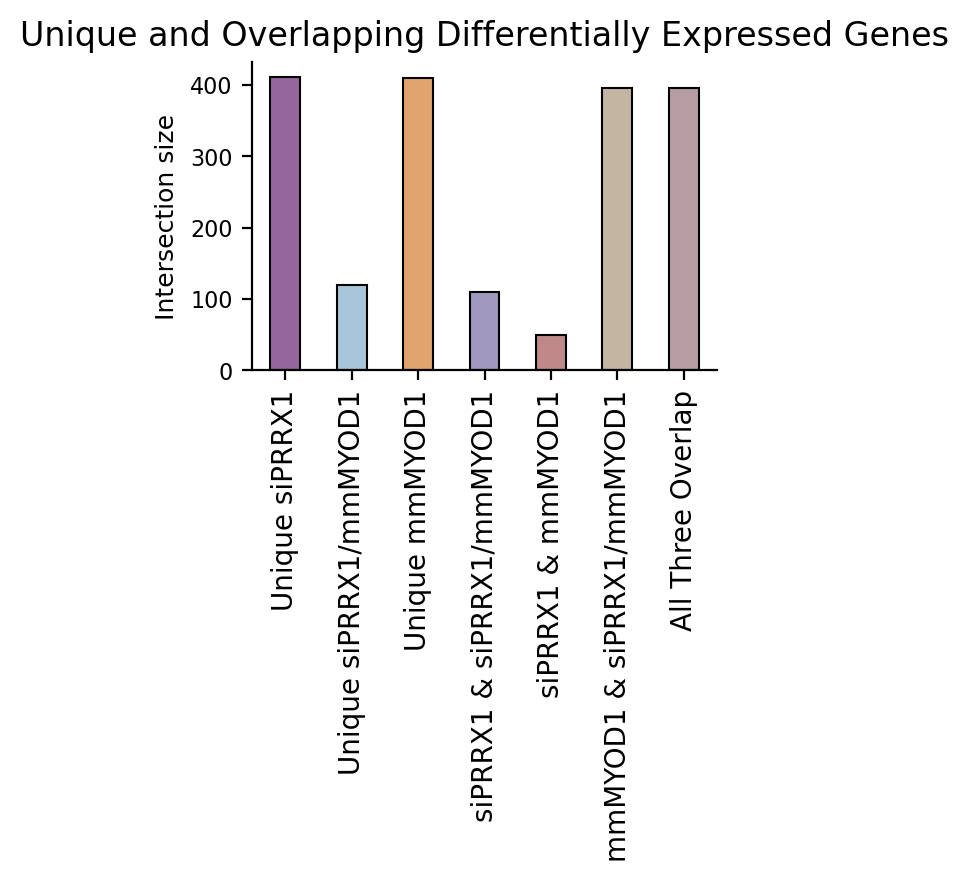

In [27]:
pdf = pdf.sort_values(['group', 'logfoldchanges'], ascending=[True, False])

siPRRX1_genes = set(pdf[pdf['group'] == 'siPRRX1']['names'])
mmMYOD1_genes = set(pdf[pdf['group'] == 'mmMYOD1']['names'])
siPRRX1_mmMYOD1_genes = set(pdf[pdf['group'] == 'siPRRX1/mmMYOD1']['names'])

ordered_conditions = [
    'Unique siPRRX1',
    'Unique siPRRX1/mmMYOD1',
    'Unique mmMYOD1',
    'siPRRX1 & siPRRX1/mmMYOD1',
    'siPRRX1 & mmMYOD1',
    'mmMYOD1 & siPRRX1/mmMYOD1',
    'All Three Overlap'
]

data = {
    'Condition': ordered_conditions,
    'Gene Count': [
        len(siPRRX1_genes - mmMYOD1_genes - siPRRX1_mmMYOD1_genes),
        len(siPRRX1_mmMYOD1_genes - siPRRX1_genes - mmMYOD1_genes),
        len(mmMYOD1_genes - siPRRX1_genes - siPRRX1_mmMYOD1_genes),
        len((siPRRX1_genes.intersection(siPRRX1_mmMYOD1_genes)) - mmMYOD1_genes),
        len((siPRRX1_genes.intersection(mmMYOD1_genes)) - siPRRX1_mmMYOD1_genes),
        len((mmMYOD1_genes.intersection(siPRRX1_mmMYOD1_genes)) - siPRRX1_genes),
        len(siPRRX1_genes.intersection(mmMYOD1_genes).intersection(siPRRX1_mmMYOD1_genes))
    ]
}

plot_df = pd.DataFrame(data)

colors = [
    "#9B5CA6", # purple 
    "#9ECAE1", # blue
    "#F5A35B", # orange
    "#9D93C3",
    "#C88081",
    "#CAB69E",
    "#BA98A1",
]  

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 2

sns.barplot(
    x='Condition',
    y='Gene Count',
    data=plot_df,
    hue='Condition',
    palette=colors,
    width=0.45,
    ec='k',
    linewidth=0.75,
)

plt.title('Unique and Overlapping Differentially Expressed Genes')
plt.xlabel('')
plt.ylabel('Intersection size', fontsize=9)
plt.xticks(rotation=90)#, ha='right')
plt.yticks(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

### Venn diagrams

In [12]:
up = pdf[pdf['logfoldchanges'] > 0]
print(f"N unique upregulated genes: {up['names'].nunique()}")

down = pdf[pdf['logfoldchanges'] < 0]
print(f"N unique downregulated genes: {down['names'].nunique()}\n")

N unique upregulated genes: 1273
N unique downregulated genes: 663



['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']


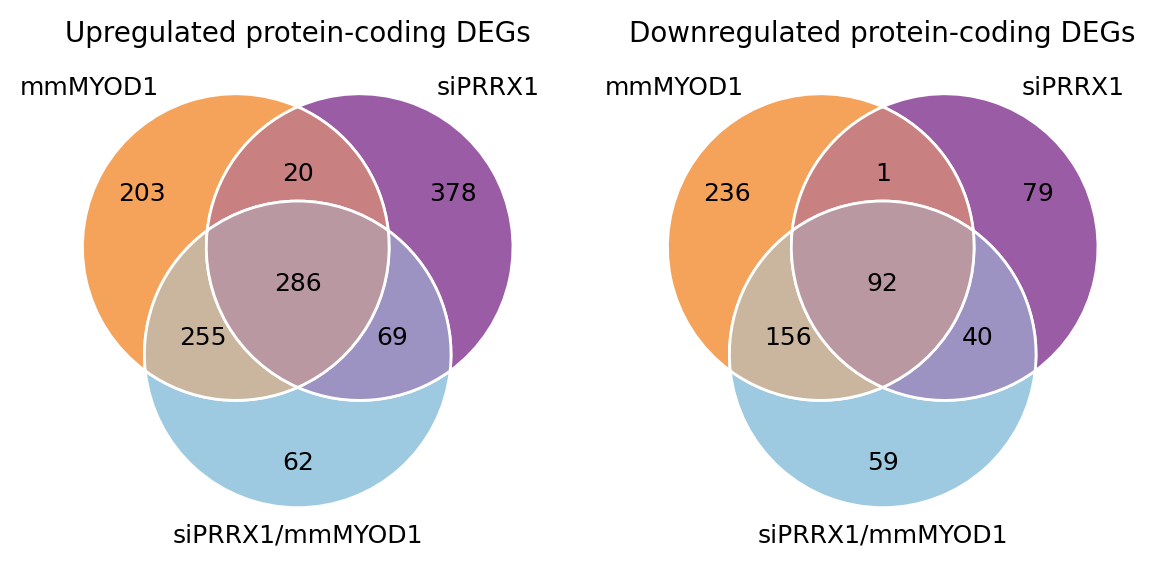

In [13]:
up_sets = up.groupby('group')['names'].apply(set).to_dict()
down_sets = down.groupby('group')['names'].apply(set).to_dict()

group_names = list(up_sets.keys())  # Assuming same groups in both
print(group_names)

# Colors
colors_rgb = {
    'mmMYOD1': mcolors.to_rgb('#F5A35B'), # orange
    'siPRRX1': mcolors.to_rgb('#9B5CA6'), # purple
    'siPRRX1/mmMYOD1': mcolors.to_rgb('#9ECAE1') # blue
}

def blend(colors):
    # get mix of 2 colors
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

venn_ids = {
    '100': ['mmMYOD1'],
    '010': ['siPRRX1'],
    '001': ['siPRRX1/mmMYOD1'],
    '110': ['mmMYOD1', 'siPRRX1'],
    '101': ['mmMYOD1', 'siPRRX1/mmMYOD1'],
    '011': ['siPRRX1', 'siPRRX1/mmMYOD1'],
    '111': ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']
}

# Plotting
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (6, 3)

fig, axs = plt.subplots(1, 2)

for ax, gene_sets, title in zip(axs, [up_sets, down_sets], ['Upregulated', 'Downregulated']):
    plt.sca(ax)  

    venn = venn3_unweighted(
        [gene_sets[group_names[0]], gene_sets[group_names[1]], gene_sets[group_names[2]]],
        set_labels=(group_names[0], group_names[1], group_names[2])
    )

    for label in venn.set_labels:
        if label:
            label.set_fontsize(9)
            
    for subset_id, sets in venn_ids.items():
        patch = venn.get_patch_by_id(subset_id)
        if patch:
            color = blend([colors_rgb[s] for s in sets])
            patch.set_facecolor(color)
            patch.set_edgecolor('white')
            patch.set_linewidth(1)
            patch.set_alpha(1)
        label = venn.get_label_by_id(subset_id)
        if label:
            label.set_fontsize(9)
            label.set_horizontalalignment('center')
            label.set_verticalalignment('center')

    ax.set_title(f"{title} protein-coding DEGs", fontsize=10)

plt.tight_layout()
plt.show()

# Make DEG overlap

In [33]:
def get_overlap_dict(df):
    """ A function to find the overlapping genes between groups """
    
    gene_sets = df.groupby('group')['names'].apply(set).to_dict()

    group1 = gene_sets['mmMYOD1']
    group2 = gene_sets['siPRRX1']
    group3 = gene_sets['siPRRX1/mmMYOD1']

    only_group1 = group1 - group2 - group3
    only_group2 = group2 - group1 - group3
    only_group3 = group3 - group1 - group2

    group1_group2 = (group1 & group2) - group3
    group1_group3 = (group1 & group3) - group2
    group2_group3 = (group2 & group3) - group1

    all_three = group1 & group2 & group3

    return {
        'mmMYOD1': only_group1,
        'siPRRX1': only_group2,
        'siPRRX1/mmMYOD1': only_group3,
        'mmMYOD1_&_siPRRX1': group1_group2,
        'mmMYOD1_&_siPRRX1/mmMYOD1': group1_group3,
        'siPRRX1_&_siPRRX1/mmMYOD1': group2_group3,
        'all': all_three
    }


up = pdf[pdf['logfoldchanges'] > 0]
down = pdf[pdf['logfoldchanges'] < 0]

up_overlap = get_overlap_dict(up)
down_overlap = get_overlap_dict(down)

print("Upregulated gene overlaps:")
for k, v in up_overlap.items():
    print(f"{k}: {len(v)}")

print("\nDownregulated gene overlaps:")
for k, v in down_overlap.items():
    print(f"{k}: {len(v)}")

Upregulated gene overlaps:
mmMYOD1: 203
siPRRX1: 378
siPRRX1/mmMYOD1: 62
mmMYOD1_&_siPRRX1: 20
mmMYOD1_&_siPRRX1/mmMYOD1: 255
siPRRX1_&_siPRRX1/mmMYOD1: 69
all: 286

Downregulated gene overlaps:
mmMYOD1: 236
siPRRX1: 79
siPRRX1/mmMYOD1: 59
mmMYOD1_&_siPRRX1: 1
mmMYOD1_&_siPRRX1/mmMYOD1: 156
siPRRX1_&_siPRRX1/mmMYOD1: 40
all: 92


643


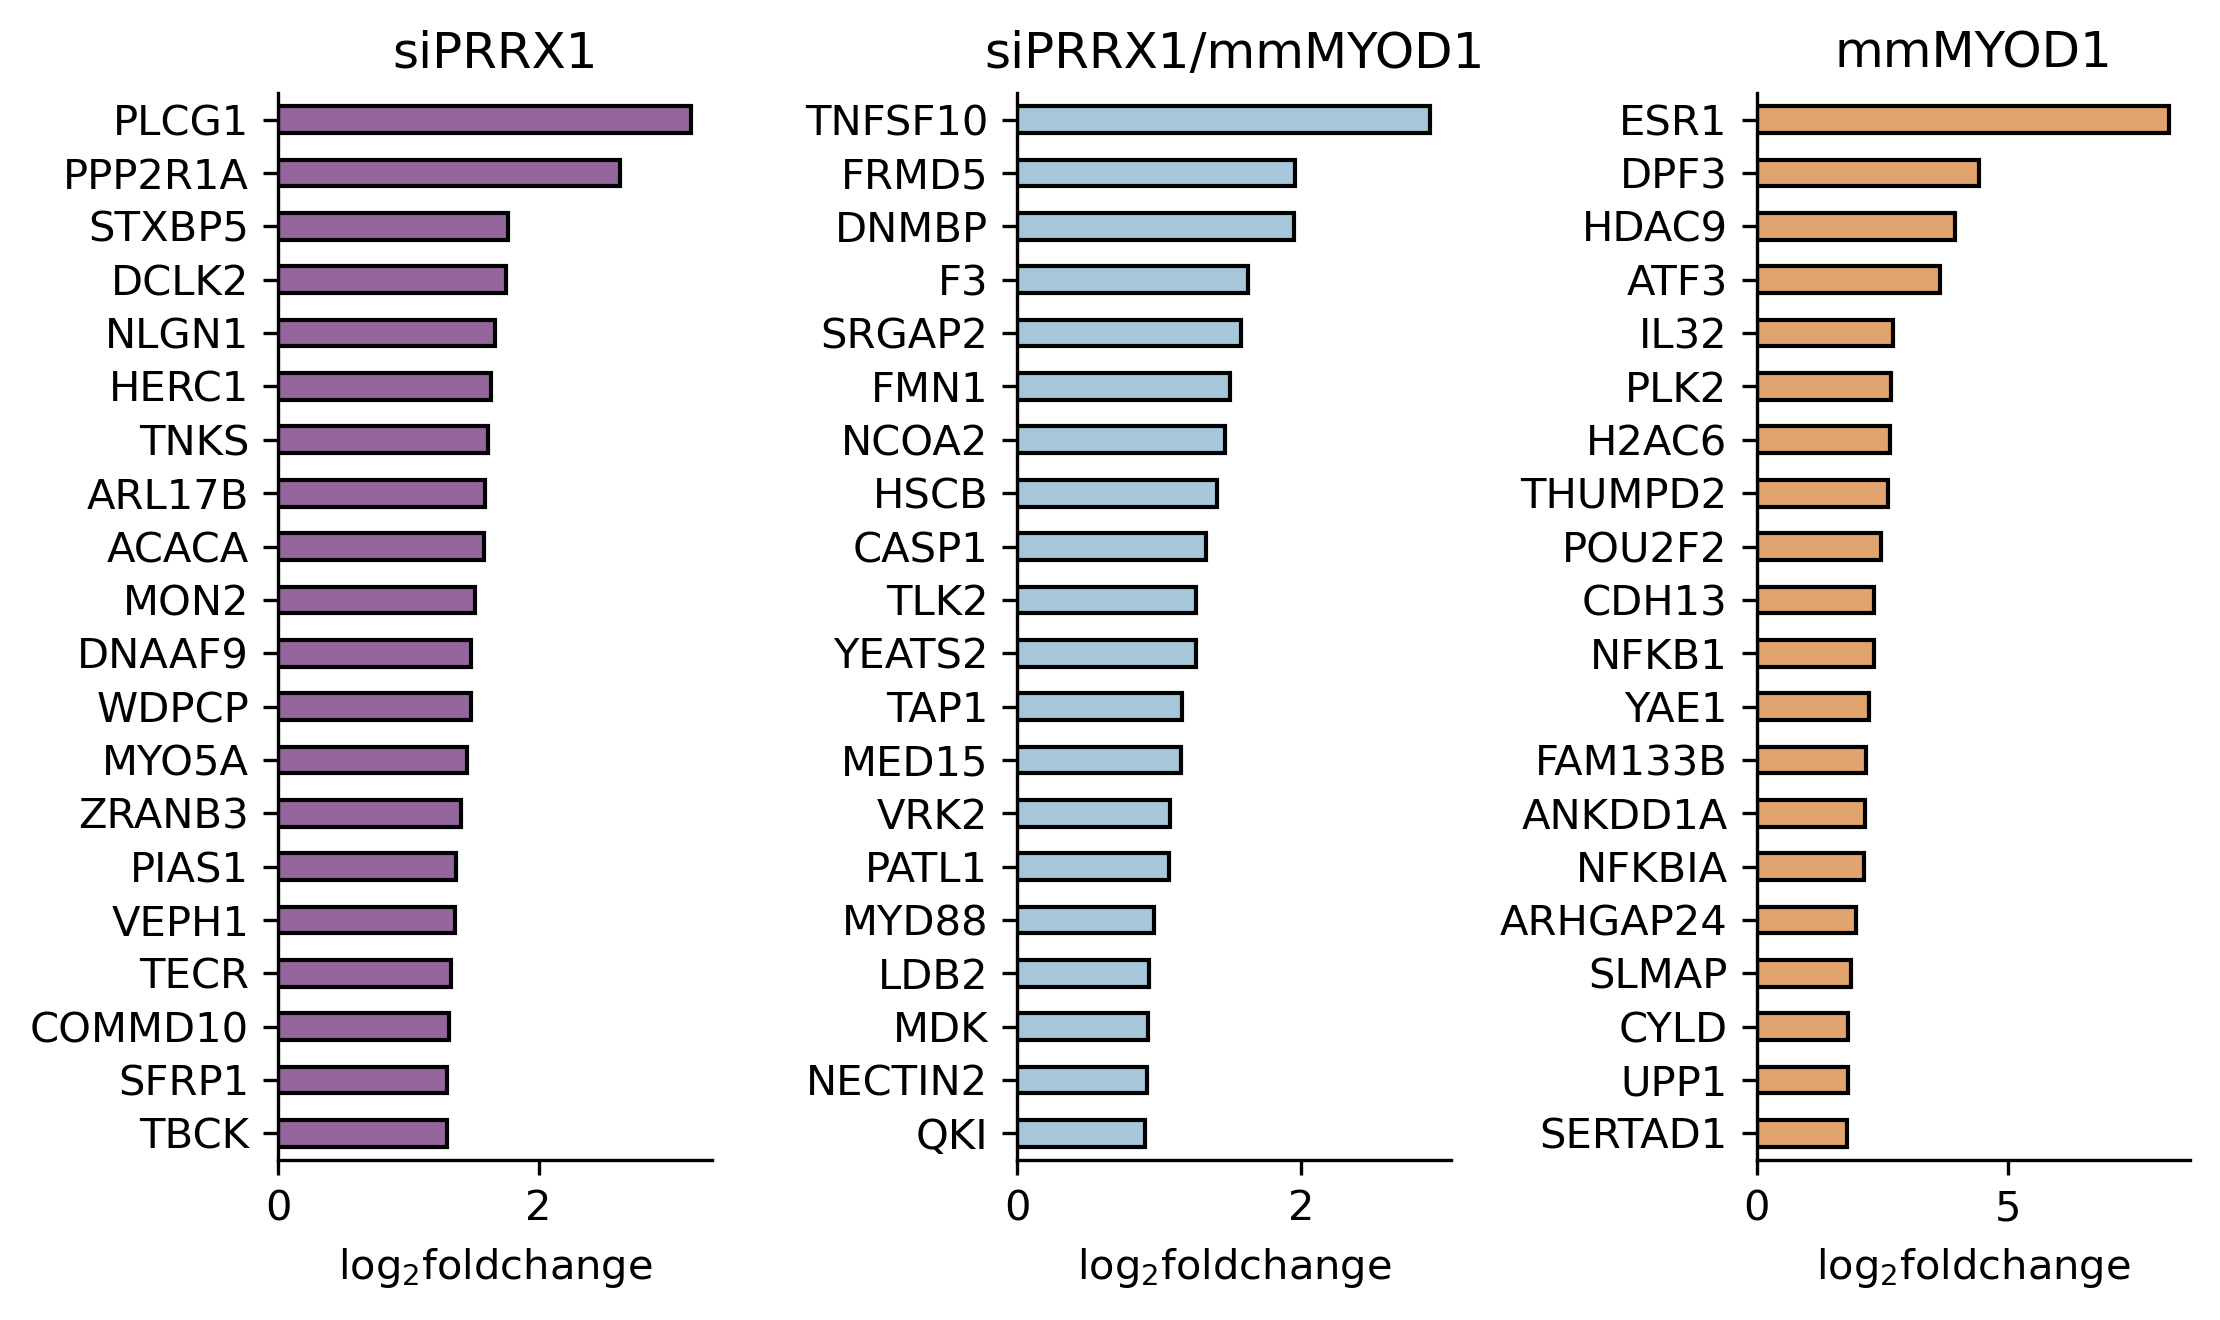

In [37]:
keys_of_interest = ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

combined = [item for key in keys_of_interest for item in up_overlap[key]]
print(len(combined))

# filter pdf for genes that are DE in only 1 condition
pdf1 = pdf[pdf['names'].isin(combined)]


color_map = {
    "siPRRX1": "#9B5CA6",
    "siPRRX1/mmMYOD1": "#9ECAE1",
    "mmMYOD1": "#F5A35B",
    "Control": "silver"
}

plot_order = ["siPRRX1", "siPRRX1/mmMYOD1", "mmMYOD1"]


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20

top_genes_per_group = {}

for group in plot_order:
    df = pdf1[pdf1['group'] == group].sort_values(by='logfoldchanges', ascending=False)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

for i, group in enumerate(plot_order): 
    df = pdf1[pdf1['group'] == group].sort_values(by='logfoldchanges', ascending=False).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

374


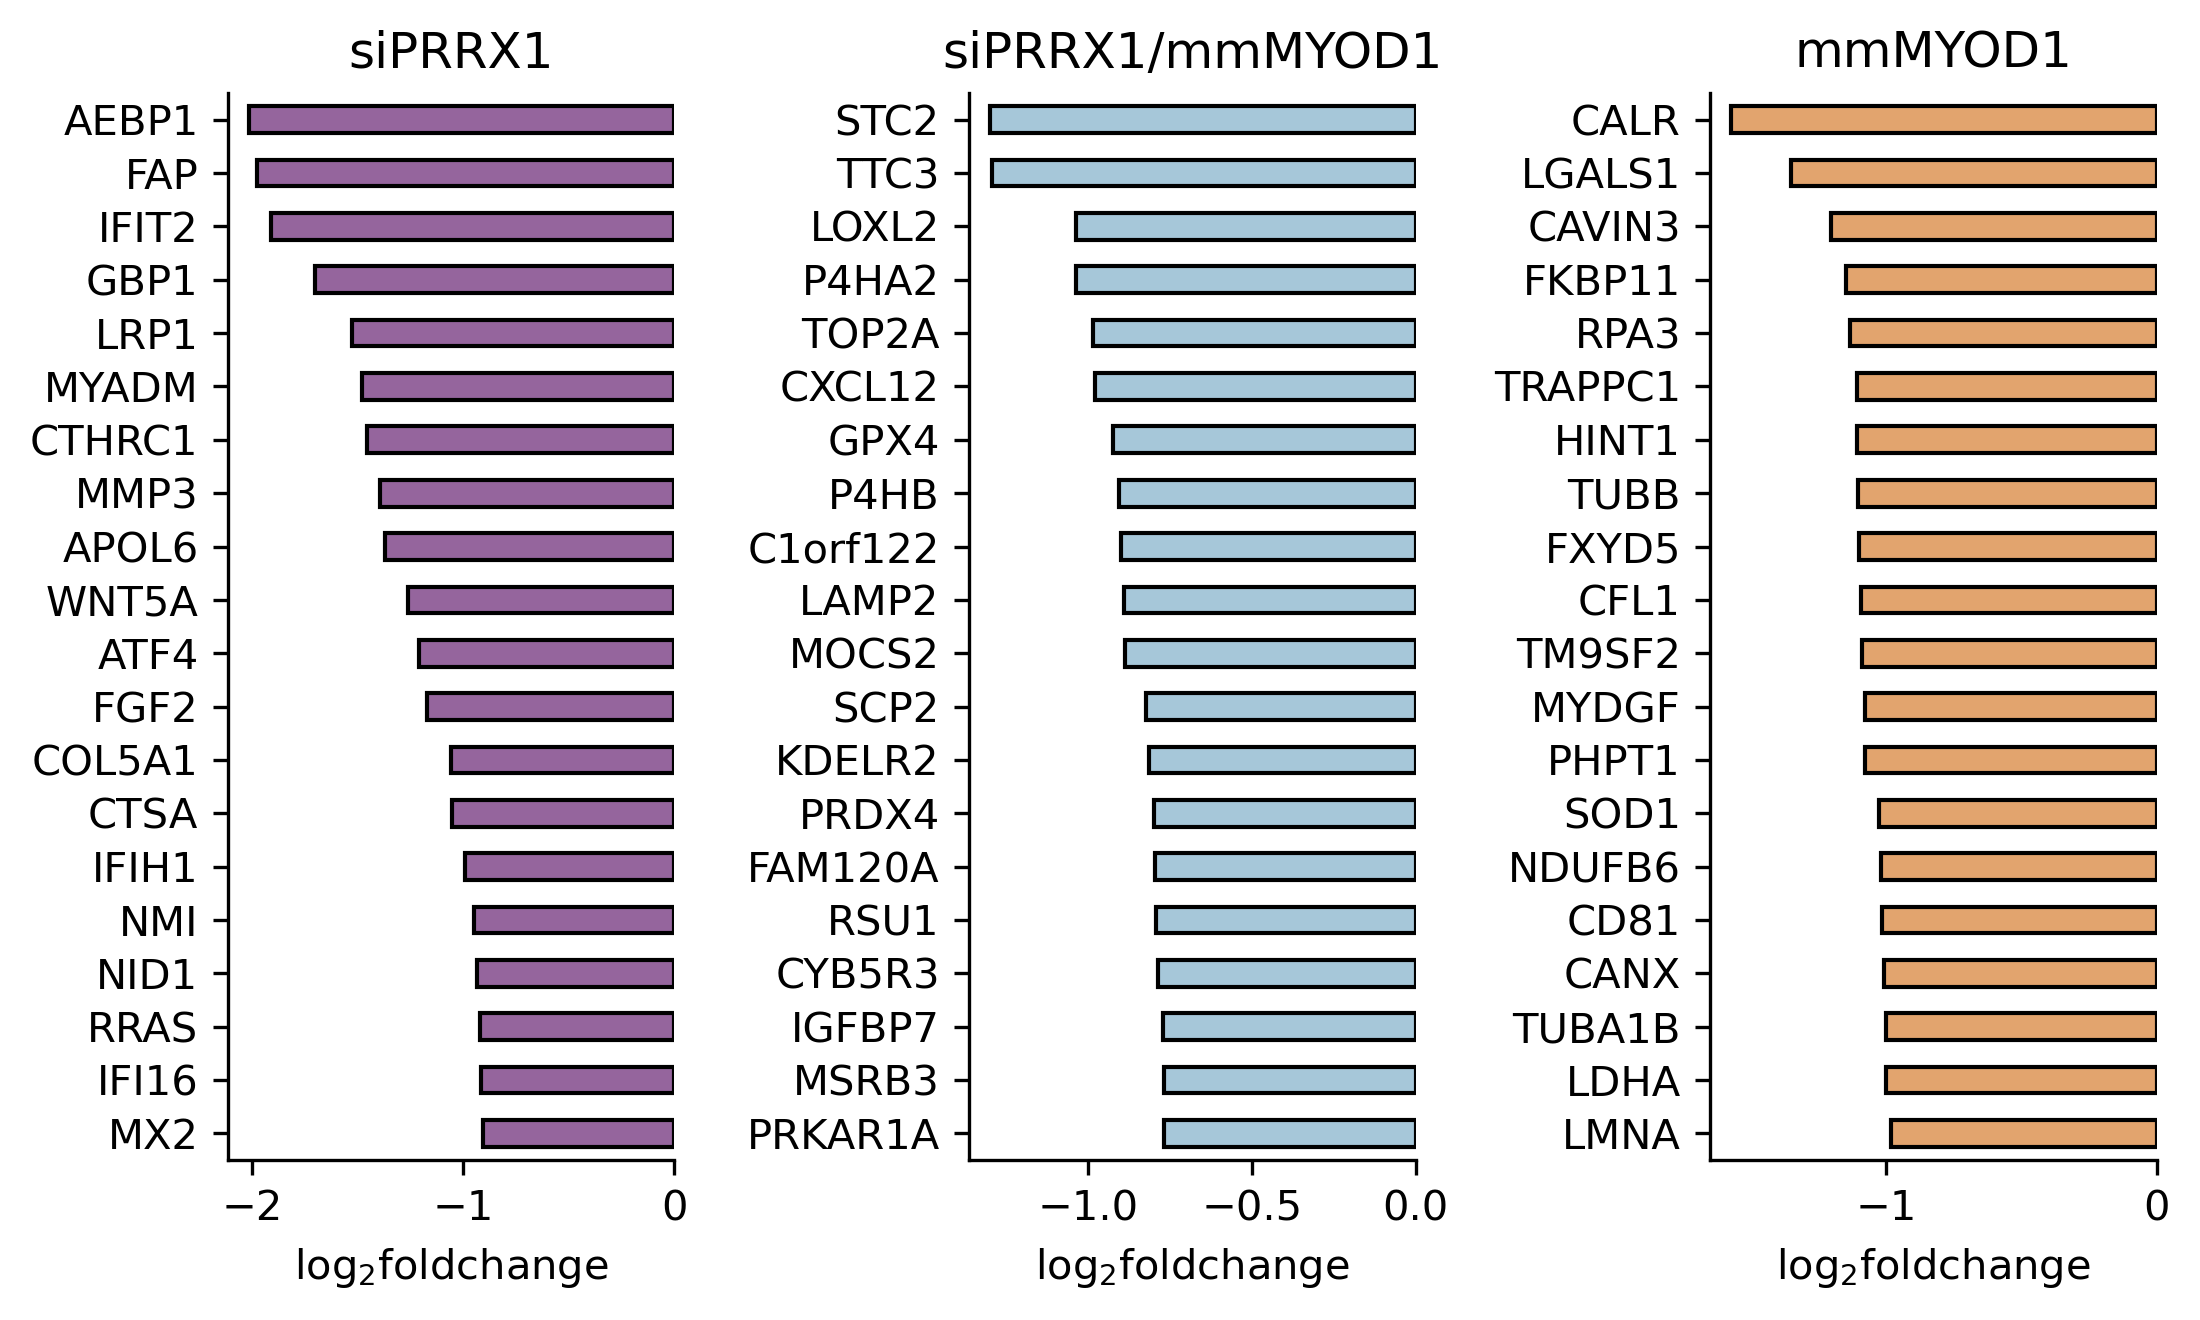

In [38]:
keys_of_interest = ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

combined = [item for key in keys_of_interest for item in down_overlap[key]]
print(len(combined))

# filter pdf for genes that are DE in only 1 condition
pdf1 = pdf[pdf['names'].isin(combined)]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20

top_genes_per_group = {}

for group in plot_order:
    df = pdf1[pdf1['group'] == group].sort_values(by='logfoldchanges', ascending=True)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

for i, group in enumerate(plot_order): 
    df = pdf1[pdf1['group'] == group].sort_values(by='logfoldchanges', ascending=True).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

In [47]:
### Create long form dataframe of gene modules of interest
records = []

for category, gene_list in categories.items():
    for gene in gene_list:
        records.append({'Category': category, 'Gene': gene})

genes_df = pd.DataFrame(records)
print(f"Using {genes_df['Category'].nunique()} modules with a total of {genes_df['Gene'].nunique()} genes.\n")


### Create dataframe with matching genes per category for each group in overlap_dict
overlap_df = []
count_dict = defaultdict(int)

# Process both up and down overlap dictionaries
for regulation_label, overlap_dict in zip(['Upregulated', 'Downregulated'], [up_overlap, down_overlap]):
    for group, genes in overlap_dict.items():
        # print(f"\nGroup: {group} ({regulation_label})")

        for gene in genes:
            match = genes_df[genes_df['Gene'] == gene]
            if not match.empty:
                categories1 = match['Category'].unique()
                category_list = ', '.join(sorted(categories1))

                # Count each category separately for this group and regulation
                for category in categories1:
                    count_dict[(group, regulation_label, category)] += 1

                overlap_df.append({
                    'group': group,
                    'names': gene,
                    'categories': category_list,
                    'regulation': regulation_label
                })

                
overlap_df = pd.DataFrame(overlap_df)

print(f"\nFinal combined dataframe has {overlap_df['names'].nunique()} unique genes across "
      f"{overlap_df['group'].nunique()} groups and both up/downregulated sets.")

overlap_df.head()

Using 12 modules with a total of 4318 genes.


Final combined dataframe has 667 unique genes across 7 groups and both up/downregulated sets.


,group,names,categories,regulation
0,mmMYOD1,RBCK1,TF_activity,Upregulated
1,mmMYOD1,BTG1,cell_cycle,Upregulated
2,mmMYOD1,FOXP1,"DNA_damage, TFs",Upregulated
3,mmMYOD1,TRIP12,"Chromatin_remodeling, DNA_damage",Upregulated
4,mmMYOD1,CWC22,AS,Upregulated


In [48]:
print(overlap_df.shape)
overlap_df[['group', 'regulation']].value_counts()

(689, 4)


group                      regulation   
siPRRX1                    Upregulated      110
all                        Upregulated       98
mmMYOD1                    Upregulated       85
mmMYOD1_&_siPRRX1/mmMYOD1  Upregulated       82
mmMYOD1                    Downregulated     75
mmMYOD1_&_siPRRX1/mmMYOD1  Downregulated     70
all                        Downregulated     51
siPRRX1                    Downregulated     37
siPRRX1_&_siPRRX1/mmMYOD1  Downregulated     22
siPRRX1/mmMYOD1            Upregulated       18
                           Downregulated     17
siPRRX1_&_siPRRX1/mmMYOD1  Upregulated       17
mmMYOD1_&_siPRRX1          Upregulated        7
Name: count, dtype: int64

In [16]:
# # Save marker gene lists to adata.uns
# for key, gene_list in categories.items():
#     adata.uns[key] = gene_list

adata

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [21]:
pivot_pdf = pdf.pivot(index='names', columns='group', values='logfoldchanges')

pivot_pdf.head()

group,mmMYOD1,siPRRX1,siPRRX1/mmMYOD1
names,,,
AAK1,NaN,-0.574401,NaN
ABCF1,0.703218,NaN,NaN
ABL2,2.530797,0.643758,2.008674
ABRACL,0.713570,NaN,0.686197
ACACA,NaN,1.579304,NaN


In [49]:
def get_logfc(row):
    group = row['group']
    gene = row['names']
    
    # Direct match
    if group in pivot_pdf.columns:
        return pivot_pdf.at[gene, group] if gene in pivot_pdf.index else np.nan
    
    # Overlap group
    elif '_&_' in group:
        parts = group.split('_&_')
        vals = []
        for part in parts:
            if gene in pivot_pdf.index and part in pivot_pdf.columns:
                val = pivot_pdf.at[gene, part]
                if pd.notna(val):
                    vals.append(val)
        if vals:
            return np.mean(vals)

    # Special case: 'all'
    elif group == 'all':
        target_groups = ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']
        vals = []
        for tg in target_groups:
            if gene in pivot_pdf.index and tg in pivot_pdf.columns:
                val = pivot_pdf.at[gene, tg]
                if pd.notna(val):
                    vals.append(val)
        if vals:
            return np.mean(vals)
    
    # Fallback
    return np.nan


tmp = overlap_df.copy()

tmp['logfoldchange'] = tmp.apply(get_logfc, axis=1)

print(tmp.shape)
tmp.tail()

(689, 5)


,group,names,categories,regulation,logfoldchange
684,all,COMMD6,TF_activity,Downregulated,-1.067537
685,all,NUPR1,"TF_activity, cell_cycle",Downregulated,-1.825972
686,all,CCDC80,"Fibroblasts, Myofibroblasts",Downregulated,-0.903690
687,all,MTDH,TF_activity,Downregulated,-0.801651
688,all,CST3,"Fibroblasts, Myofibroblasts",Downregulated,-2.717282


In [50]:
tmp = tmp.sort_values(by=['group', 'logfoldchange'], ascending=[True, False])

tmp.groupby('group').head()

,group,names,categories,regulation,logfoldchange
332,all,ZSCAN30,TFs,Upregulated,3.553197
358,all,NFAT5,"Chromatin_remodeling, DNA_damage, Fibroblasts,...",Upregulated,2.276215
398,all,GMNN,"Chromatin_remodeling, cell_cycle",Upregulated,2.058218
362,all,FMN2,DNA_damage,Upregulated,1.814696
350,all,SETD5,Chromatin_remodeling,Upregulated,1.775936
21,mmMYOD1,ESR1,"Chromatin_remodeling, TF_activity, TFs",Upregulated,8.198524
17,mmMYOD1,DPF3,"Chromatin_remodeling, cell_cycle",Upregulated,4.407542
26,mmMYOD1,HDAC9,Core_reprogramming,Upregulated,3.932225
59,mmMYOD1,ATF3,"Fibroblasts, TFs",Upregulated,3.641632
79,mmMYOD1,PLK2,"DNA_damage, cell_cycle",Upregulated,2.670010


In [53]:
grup = 'siPRRX1'

tmp[tmp['group'] == grup].head(50)

,group,names,categories,regulation,logfoldchange
98,siPRRX1,NLGN1,Circadian,Upregulated,1.663753
164,siPRRX1,ZRANB3,DNA_damage,Upregulated,1.405439
144,siPRRX1,SFRP1,cell_cycle,Upregulated,1.295312
181,siPRRX1,CDKN3,cell_cycle,Upregulated,1.264382
140,siPRRX1,SCMH1,"Chromatin_remodeling, TFs",Upregulated,1.173311
129,siPRRX1,ITGA3,Myogenic,Upregulated,1.134290
89,siPRRX1,CLASP2,cell_cycle,Upregulated,1.119320
184,siPRRX1,NPM1,"Chromatin_remodeling, DNA_damage, TF_activity,...",Upregulated,1.073912
159,siPRRX1,LCORL,TFs,Upregulated,1.070558
88,siPRRX1,CD248,Fibroblasts,Upregulated,1.064801


# Unique per individual condition

In [19]:
individual_conditions = ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

sdf = overlap_df[overlap_df['group'].isin(individual_conditions)]

# merge with DEG dataframe to get logfoldchanges
sdf = pd.merge(sdf, pdf, how='left', on=["group", "names"])

sdf = sdf.drop(columns=['gene_type', 'mt', 'pvals'])

print(sdf.shape)
sdf.head()

(331, 11)


,group,names,categories,regulation,Unnamed: 0,scores,logfoldchanges,pvals_adj,pct_nz_group,abs_lfc,ribo
0,mmMYOD1,BTG1,cell_cycle,Upregulated,1106,14.230192,0.944051,7.392278e-45,0.577571,0.944051,False
1,mmMYOD1,FOXP1,"DNA_damage, TFs",Upregulated,1083,14.489382,0.836343,1.789065e-46,0.598404,0.836343,False
2,mmMYOD1,TRIP12,"Chromatin_remodeling, DNA_damage",Upregulated,757,17.182016,0.547028,6.164158e-65,0.791667,0.547028,False
3,mmMYOD1,CWC22,AS,Upregulated,1121,14.137776,0.839856,2.732688e-44,0.560727,0.839856,False
4,mmMYOD1,IRF2,TFs,Upregulated,1259,13.189695,0.517199,1.123310e-38,0.710550,0.517199,False


In [20]:
# inspect top upregulated
sdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False]).groupby('group').head()

,group,names,categories,regulation,Unnamed: 0,scores,logfoldchanges,pvals_adj,pct_nz_group,abs_lfc,ribo
20,mmMYOD1,ESR1,"Chromatin_remodeling, TFs",Upregulated,56,37.710102,8.198524,0.000000e+00,0.530142,8.198524,False
16,mmMYOD1,DPF3,"Chromatin_remodeling, cell_cycle",Upregulated,71,35.857616,4.407542,1.278410e-279,0.548316,4.407542,False
25,mmMYOD1,HDAC9,Core_reprogramming,Upregulated,84,34.441345,3.932225,5.099567e-258,0.549645,3.932225,False
56,mmMYOD1,ATF3,"Fibroblasts, TFs",Upregulated,135,31.300402,3.641632,2.901790e-213,0.539007,3.641632,False
75,mmMYOD1,PLK2,"DNA_damage, cell_cycle",Upregulated,245,26.234589,2.670010,4.240357e-150,0.525266,2.670010,False
94,siPRRX1,NLGN1,Circadian,Upregulated,25366,27.740114,1.663753,1.271947e-167,0.573756,1.663753,False
159,siPRRX1,ZRANB3,DNA_damage,Upregulated,25491,23.726763,1.405439,7.566796e-123,0.505674,1.405439,False
139,siPRRX1,SFRP1,cell_cycle,Upregulated,25320,29.304419,1.295312,5.824502e-187,0.691301,1.295312,False
176,siPRRX1,CDKN3,cell_cycle,Upregulated,25322,29.252142,1.264382,2.682603e-186,0.718941,1.264382,False
135,siPRRX1,SCMH1,"Chromatin_remodeling, TFs",Upregulated,25561,22.166225,1.173311,2.473902e-107,0.540879,1.173311,False


In [ ]:
# which genes are up

In [29]:
both = sdf[sdf['group'] == 'siPRRX1/mmMYOD1'].sort_values(by='scores', ascending=False)

both

,group,names,categories,regulation,scores,logfoldchanges,pvals_adj,pct_nz_group,abs_lfc,ribo
197,siPRRX1/mmMYOD1,SMARCA5,"Chromatin_remodeling, DNA_damage, TFs, cell_cycle",Upregulated,37.454784,0.718160,4.620748e-305,0.969382,0.718160,False
195,siPRRX1/mmMYOD1,VAMP5,Core_reprogramming,Upregulated,36.342079,0.709352,2.995595e-287,0.956961,0.709352,False
200,siPRRX1/mmMYOD1,PSMA6,TFs,Upregulated,35.047504,0.664875,3.373235e-267,0.940497,0.664875,False
194,siPRRX1/mmMYOD1,LIMA1,Fibroblasts,Upregulated,31.900602,0.559772,1.691740e-221,0.984113,0.559772,False
204,siPRRX1/mmMYOD1,MDK,Fibroblasts,Upregulated,30.688732,0.919825,4.690841e-205,0.879549,0.919825,False
196,siPRRX1/mmMYOD1,PTN,"Core_reprogramming, Fibroblasts, Myofibroblasts",Upregulated,27.300358,0.709595,1.905028e-162,0.898325,0.709595,False
203,siPRRX1/mmMYOD1,NCOA2,TFs,Upregulated,25.021229,1.460178,1.353079e-136,0.532929,1.460178,False
206,siPRRX1/mmMYOD1,YEATS2,"Chromatin_remodeling, cell_cycle",Upregulated,22.088955,1.256707,1.181970e-106,0.515309,1.256707,False
190,siPRRX1/mmMYOD1,TLK2,"Chromatin_remodeling, DNA_damage",Upregulated,22.021290,1.260429,5.218262e-106,0.513576,1.260429,False
193,siPRRX1/mmMYOD1,MYD88,Myogenic,Upregulated,21.435009,0.959439,1.724930e-100,0.601386,0.959439,False


In [28]:
sdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, True]).groupby('group').head()

,group,names,categories,regulation,scores,logfoldchanges,pvals_adj,pct_nz_group,abs_lfc,ribo
230,mmMYOD1,CALR,cell_cycle,Downregulated,-40.245644,-1.571018,0.000000e+00,0.619681,1.571018,False
278,mmMYOD1,LGALS1,"Fibroblasts, Myofibroblasts, Myogenic",Downregulated,-56.058929,-1.352489,0.000000e+00,0.996454,1.352489,False
220,mmMYOD1,RPA3,DNA_damage,Downregulated,-25.605413,-1.133452,5.001839e-143,0.517287,1.133452,False
237,mmMYOD1,SOD1,TFs,Downregulated,-37.887856,-1.025112,0.000000e+00,0.854167,1.025112,False
276,mmMYOD1,CD81,"Fibroblasts, Myofibroblasts",Downregulated,-24.688671,-1.016110,4.980761e-133,0.504433,1.016110,False
296,siPRRX1,FAP,"Fibroblasts, Myofibroblasts",Downregulated,-58.522789,-1.978740,0.000000e+00,0.626709,1.978740,False
300,siPRRX1,LRP1,Myofibroblasts,Downregulated,-47.249660,-1.526755,0.000000e+00,0.624091,1.526755,False
281,siPRRX1,CTHRC1,Fibroblasts,Downregulated,-34.278809,-1.458492,1.563245e-255,0.542333,1.458492,False
298,siPRRX1,MMP3,Fibroblasts,Downregulated,-26.244715,-1.397318,3.976103e-150,0.558336,1.397318,False
301,siPRRX1,WNT5A,Core_reprogramming,Downregulated,-32.677292,-1.262003,2.834733e-232,0.572010,1.262003,False


In [ ]:
# load in SCENIC database, get targets of MYOD1 and PRRX1, look for those

/home/jrcwycy/miniconda3/envs/scanpy/lib/python3.12/site-packages/anndata/_core/anndata.py:602: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)


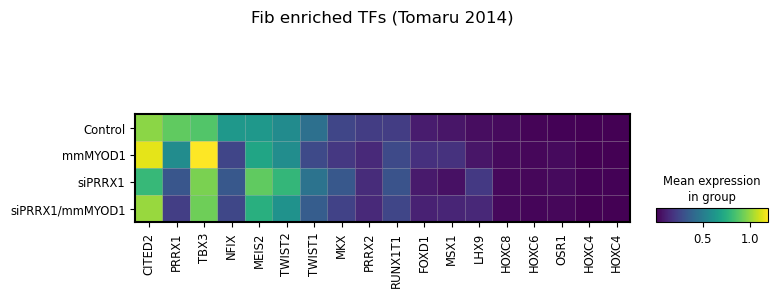

In [47]:
key_fib_tfs = ['PRRX1', 'OSR1', 'FOXD1', 'HOXC4', 'LHX9', 'TBX3', 'TWIST2',
               'MKX', 'PRRX2', 'MSX1', 'TWIST1', 'CITED2', 'RUNX1T1', 'NFIX', 'HOXB5', 'HOXC8', 'MEIS2', 'HOXC6', 'HOXC4',
              ]

control_adata = adata[adata.obs['pooled_condition'] == 'Control']

valid_genes = [g for g in key_fib_tfs if g in control_adata.var_names]

control_adata.X = control_adata.layers['log_norm'].copy()

# Get mean expression per gene in Control group
mean_expr = control_adata[:, valid_genes].X.mean(axis=0)

# If sparse, convert to dense
if hasattr(mean_expr, "A1"):
    mean_expr = mean_expr.A1  # flatten sparse matrix to 1D array

# Create a sorted gene list by mean expression
sorted_genes = pd.Series(mean_expr, index=valid_genes).sort_values(ascending=False).index.tolist()


sc.pl.matrixplot(
    adata,
    var_names=sorted_genes,
    groupby='pooled_condition',
    use_raw=False,
    layer='log_norm',
    # standard_scale='var',
    title='Fib enriched TFs (Tomaru 2014)',
)

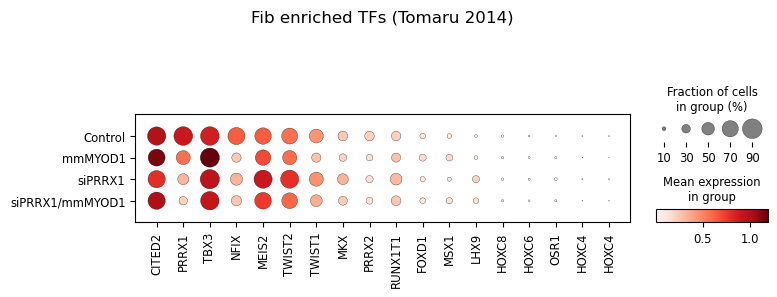

In [48]:
sc.pl.dotplot(
    adata,
    var_names=sorted_genes,
    groupby='pooled_condition',
    use_raw=False,
    layer='log_norm',
    # standard_scale='var',
    title='Fib enriched TFs (Tomaru 2014)',
)

In [63]:
# counts_data = {}

# # Iterate through each experiment group in overlap_dict
# for group, genes_in_group in overlap_dict.items():
#     counts_data[group] = {}
#     # Iterate through each category
#     for category_name, marker_genes_list in categories.items():
#         # Count how many genes from the experiment group are in the current marker gene category
#         count = sum(1 for gene in genes_in_group if gene in marker_genes_list)
#         counts_data[group][category_name] = count


# odf = pd.DataFrame.from_dict(counts_data, orient='index')
# odf.index.name = 'Group'
# odf.columns.name = 'Category'
# odf

Category,TFs,Fibroblasts,Myogenic,cell_cycle,AS,Circadian,Core_reprogramming
Group,,,,,,,
mmMYOD1,34,11,7,14,13,0,5
siPRRX1,25,17,6,37,21,3,1
siPRRX1/mmMYOD1,5,3,1,4,2,0,2
mmMYOD1_vs_siPRRX1,2,0,3,1,2,1,1
mmMYOD1_vs_siPRRX1/mmMYOD1,26,10,6,21,7,1,8
siPRRX1_vs_siPRRX1/mmMYOD1,6,3,1,3,2,0,0
all,26,7,7,32,14,2,2


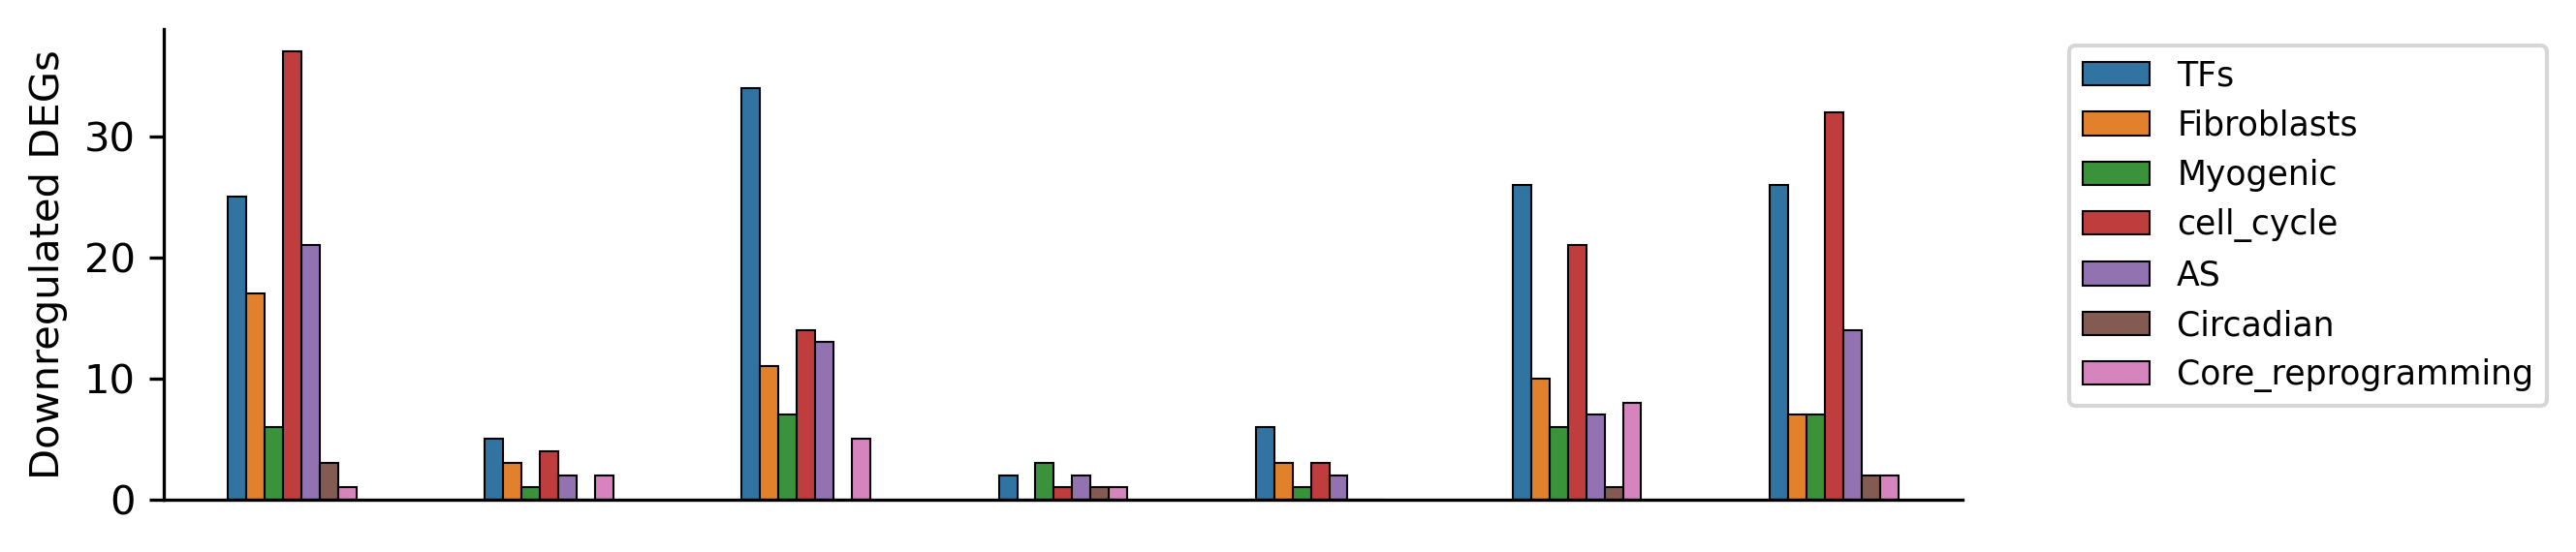

In [64]:
# count_long = odf.reset_index().melt(id_vars='Group', var_name='Category', value_name='Gene_Count')

# plt.rcParams['figure.dpi'] = 300
# plt.figure(figsize=(9, 2))


# group_order = ['siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1', 'mmMYOD1_vs_siPRRX1',
#                'siPRRX1_vs_siPRRX1/mmMYOD1', 'mmMYOD1_vs_siPRRX1/mmMYOD1', 'all'
#               ]

# sns.barplot(
#     data=count_long,
#     x='Group',
#     y='Gene_Count',
#     hue='Category',
#     dodge=True,
#     ec='k',
#     width=0.5,
#     linewidth=0.5,
#     order=group_order,
# )

# plt.ylabel("Downregulated DEGs")
# plt.xticks([])
# plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
# plt.xlabel("")
# plt.tight_layout()
# sns.despine()
# plt.show()

In [49]:
adata

AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [50]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"

bdata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

bdata

Memory usage: current 4.65 GB, difference +1.96 GB
Total time: 5.28 seconds


AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [51]:
bdata.obs['dataset'].value_counts()

dataset
Hybrid     9407
Control    6960
Name: count, dtype: int64